<a href="https://colab.research.google.com/github/hongdaoyang512-bit/Stock_Analysis/blob/main/Stock_Market_Prediction(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv')

In [71]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [52]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6290 non-null   object 
 1   Open       6290 non-null   float64
 2   High       6290 non-null   float64
 3   Low        6290 non-null   float64
 4   Close      6290 non-null   float64
 5   Adj Close  6290 non-null   float64
 6   Volume     6290 non-null   int64  
 7   Ticker     6290 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
std,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07
min,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08


In [53]:
#Check if there are duplicates or null values
print(df.duplicated().sum())
df.isna().sum()

0


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Ticker,0


In [73]:
#Return 6 largest values in 'Volume'
df_volSort = df.sort_values('Volume', ascending=False)
df_volSort.head(7)

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
5306,2020-02-04,58.863998,64.599335,55.591999,59.137333,59.137333,914082000,TSLA
5307,2020-02-05,54.883999,56.398666,46.940666,48.980000,48.980000,726357000,TSLA
5305,2020-02-03,44.912666,52.409332,44.901333,52.000000,52.000000,705975000,TSLA
5528,2020-12-18,222.966660,231.666672,209.513336,231.666672,231.666672,666378600,TSLA
5308,2020-02-06,46.661331,53.055332,45.799999,49.930668,49.930668,598212000,TSLA
5416,2020-07-13,110.599998,119.666000,98.073997,99.804001,99.804001,584781000,TSLA
5367,2020-05-01,50.333332,51.518002,45.535999,46.754665,46.754665,487977000,TSLA


In [74]:
#drop 6 largest outliers in'Volume'
df_cleaned = df[df["Volume"]<584781000]
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6284 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6284 non-null   object 
 1   Open       6284 non-null   float64
 2   High       6284 non-null   float64
 3   Low        6284 non-null   float64
 4   Close      6284 non-null   float64
 5   Adj Close  6284 non-null   float64
 6   Volume     6284 non-null   int64  
 7   Ticker     6284 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 441.8+ KB


In [83]:
#Converting 'date' column to datetime and sort it
pd.to_datetime(df_cleaned['Date'])
df_cleaned = df_cleaned.sort_values("Date")

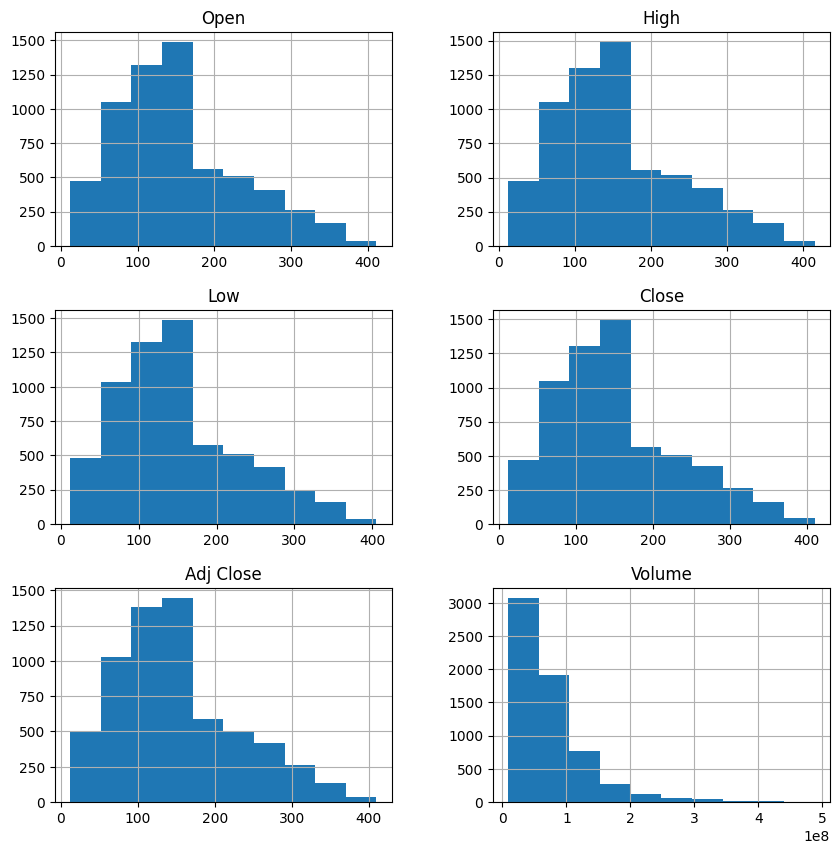

In [79]:
#Histograms
import matplotlib.pyplot as plt

prices = df_cleaned[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]
prices.hist(figsize=(10, 10))
plt.show()

               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.999566  0.999441  0.998990   0.998668 -0.271650
High       0.999566  1.000000  0.999212  0.999470   0.999303 -0.263084
Low        0.999441  0.999212  1.000000  0.999510   0.999017 -0.281247
Close      0.998990  0.999470  0.999510  1.000000   0.999668 -0.271609
Adj Close  0.998668  0.999303  0.999017  0.999668   1.000000 -0.266598
Volume    -0.271650 -0.263084 -0.281247 -0.271609  -0.266598  1.000000


<Axes: >

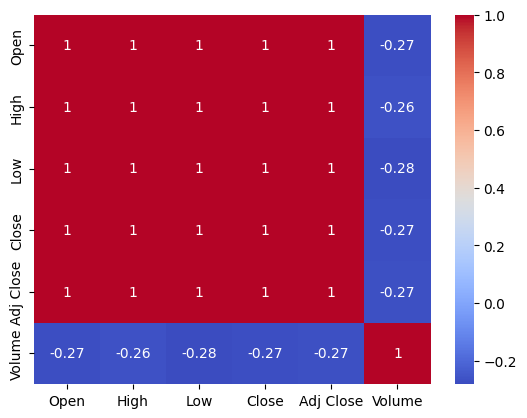

In [80]:
#Checking the correlation between variables
corrMatrix = prices.corr()
print(corrMatrix)
#Heatmap of correlation between variables
import seaborn as sns
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm')

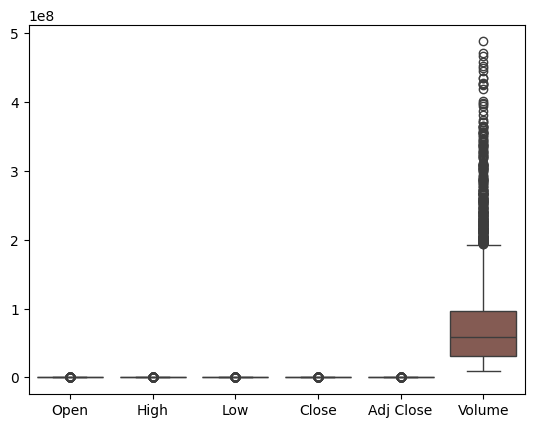

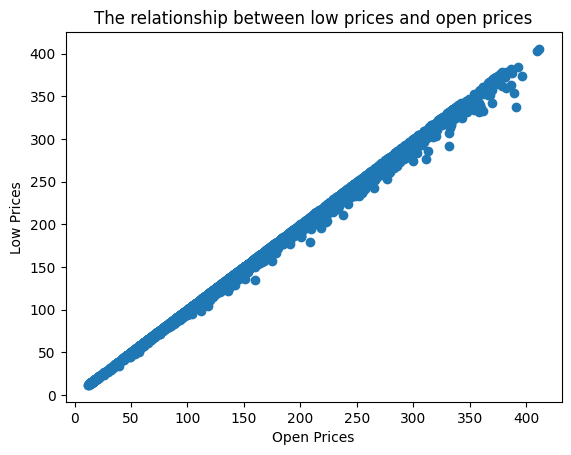

In [92]:
#Boxplots
sns.boxplot(prices)
plt.show()

#Scatter plot
plt.title('The relationship between low prices and open prices')
plt.scatter(df_cleaned['Open'], df_cleaned['Low'])
plt.xlabel('Open Prices')
plt.ylabel('Low Prices')
plt.show()